# Which Data Fits Which Classifier?
## An Object-Oriented Testbed for Model- and Domain-Specific Data Suitability on Korean NLI

**실험 설계**

| 축 | 값 |
|---|---|
| 과제 | KLUE-NLI 3분류 (entailment=0 / neutral=1 / contradiction=2) |
| 모델 | KNN vs NN(NumPy 직접 구현) vs BERT |
| 학습 풀 | 격식체(formal) / 구어체(colloquial) / 전체(combined) |
| 학습량 통제 | 각 풀 6,000건 (라벨별 2,000) |
| 핵심 비교 | 목표 도메인별 **targeted(목표풀만) vs broad(전체)** |
| 평가 | 목표 도메인의 **test 슬라이스**로만 (격식체 1,800 / 구어체 1,200) |

원칙: 학습량 통제 · 목표 슬라이스 평가 · 결과는 이 데이터 한정.

## 1단계 — 환경 확인 + 데이터 로드

- M3 Mac의 MPS 가속 확인.
- `klue/klue` (config `nli`) 로드. `"klue"` 단독은 에러 → 반드시 `"klue/klue"`.
- source 분포로 격식체/구어체 도메인 구성 확인.

In [1]:
import torch
from datasets import load_dataset
from collections import Counter

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"PyTorch device: {device}")

ds = load_dataset("klue/klue", "nli")
print(ds)
print("label feature:", ds["train"].features["label"])
print("\nsource distribution (train):")
for s, c in Counter(ds["train"]["source"]).most_common():
    print(f"  {s}: {c}")

/Users/idawon/Desktop/OOP_subject/nli_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch device: mps


DatasetDict({
    train: Dataset({
        features: ['guid', 'source', 'premise', 'hypothesis', 'label'],
        num_rows: 24998
    })
    validation: Dataset({
        features: ['guid', 'source', 'premise', 'hypothesis', 'label'],
        num_rows: 3000
    })
})
label feature: ClassLabel(names=['entailment', 'neutral', 'contradiction'])

source distribution (train):
  NSMC: 4899
  airbnb: 4824
  wikitree: 3838
  policy: 3833
  wikinews: 3824
  wikipedia: 3780


## 2단계 — 세 학습 풀 분할 (격식체 / 구어체 / 전체), 각 6,000건 통제

- **격식체(formal)** = {`wikipedia`, `wikinews`, `wikitree`, `policy`}
- **구어체(colloquial)** = {`NSMC`, `airbnb`}
- **전체(combined)** = 전체 (broad 전략의 학습 풀)
- 세 풀 모두 6,000건(라벨별 2,000)으로 통제 — 데이터 양이 아닌 "종류"만 변하게.

연구 질문: 목표 풀에서 잘하려면 (targeted) 그 풀만 학습 vs (broad) 전체 학습? — 평가는 7단계에서 목표의 test 슬라이스로.

In [2]:
import random
random.seed(42)

FORMAL_SOURCES = {"wikipedia", "wikinews", "wikitree", "policy"}
COLLOQUIAL_SOURCES = {"NSMC", "airbnb"}
N_PER_DOMAIN = 6000

train = ds["train"]
labels = train["label"]
sources = train["source"]

formal_idx = [i for i, s in enumerate(sources) if s in FORMAL_SOURCES]
colloquial_idx = [i for i, s in enumerate(sources) if s in COLLOQUIAL_SOURCES]
all_idx = list(range(len(train)))


def stratified_sample(indices, n_total, labels):
    """라벨별로 균등하게 n_total건을 층화 추출."""
    by_label = {0: [], 1: [], 2: []}
    for i in indices:
        by_label[labels[i]].append(i)
    n_each = n_total // 3
    sampled = []
    for lab in [0, 1, 2]:
        pool = by_label[lab]
        random.shuffle(pool)
        sampled.extend(pool[:n_each])
    random.shuffle(sampled)
    return sampled


# 세 학습 풀: 격식체(formal) / 구어체(colloquial) / 전체(combined)
formal_train = train.select(stratified_sample(formal_idx, N_PER_DOMAIN, labels))
colloquial_train = train.select(stratified_sample(colloquial_idx, N_PER_DOMAIN, labels))
combined_train = train.select(stratified_sample(all_idx, N_PER_DOMAIN, labels))
val = ds["validation"]

for name, d in [("격식체", formal_train), ("구어체", colloquial_train), ("통합", combined_train)]:
    print(f"{name} 학습셋: {len(d)}건  라벨 {dict(Counter(d['label']))}")
    print(f"  출처 {dict(Counter(d['source']))}")
print(f"평가셋(고정): {len(val)}건  라벨 {dict(Counter(val['label']))}")

격식체 학습셋: 6000건  라벨 {1: 2000, 2: 2000, 0: 2000}
  출처 {'wikitree': 1536, 'policy': 1499, 'wikinews': 1473, 'wikipedia': 1492}
구어체 학습셋: 6000건  라벨 {0: 2000, 1: 2000, 2: 2000}
  출처 {'airbnb': 2993, 'NSMC': 3007}


통합 학습셋: 6000건  라벨 {0: 2000, 1: 2000, 2: 2000}
  출처 {'wikipedia': 885, 'wikitree': 915, 'NSMC': 1169, 'airbnb': 1147, 'wikinews': 944, 'policy': 940}
평가셋(고정): 3000건  라벨 {2: 1000, 1: 1000, 0: 1000}


## 3단계 — OOP 임베딩 계층 + SBERT 벡터 추출

교재(Lott & Phillips, *Python OOP*)의 Iris-KNN 사례를 NLI로 재설계한 객체지향 구조의 **임베딩 계층**을 정의한다.

| 클래스 | 역할 | OOP 개념 |
|---|---|---|
| `InvalidSampleError(ValueError)` | 잘못된 샘플 예외 | 커스텀 예외, `raise ... from` |
| `NLISample` | premise·hypothesis 두 문장 캡슐화 | 캡슐화, `from_dict` 팩토리 |
| `KnownNLI(NLISample)` | 라벨이 붙은 학습 샘플 | 상속, `super().__init__` |
| `Embedder(ABC)` | 임베딩 전략 추상 인터페이스 | 추상화, 전략 패턴 |
| `SBERTEmbedder(Embedder)` | 한국어 SBERT 구현체 | OCP — 새 임베딩은 서브클래스만 추가 |

**문장쌍 결합**: premise 벡터 `u`, hypothesis 벡터 `v`를 `concat[u, v, |u−v|, u⊙v]`로 묶어 4×768 = 3072차원 한 벡터를 만든다. `|u−v|`(차이)와 `u⊙v`(요소곱)는 NLI에서 두 문장의 관계를 드러내는 표준 결합 방식.

> **한계(논문에 명시)**: 두 문장을 한 벡터로 합치면 joint-attention 모델이 잡는 토큰 단위 상호작용 일부를 잃는다. 이는 KNN/NN의 구조적 제약이며 BERT(직접 처리)와의 대비 포인트.

임베딩 모델은 범용 한국어 SBERT `jhgan/ko-sroberta-multitask` (KLUE-NLI로 사전학습되지 않아 KNN/NN 성능을 과대평가하지 않음). 결과는 `emb/*.npy`로 캐시해 4단계에서 재사용.

In [3]:
from abc import ABC, abstractmethod
import numpy as np


class InvalidSampleError(ValueError):
    """premise/hypothesis가 비었거나 키가 없는 샘플."""


class NLISample:
    """전제(premise)와 가설(hypothesis) 두 문장을 캡슐화한 추론 단위."""

    def __init__(self, premise: str, hypothesis: str) -> None:
        if not premise or not hypothesis:
            raise InvalidSampleError(
                f"premise/hypothesis가 모두 필요: {premise!r}, {hypothesis!r}"
            )
        self.premise = premise
        self.hypothesis = hypothesis

    @classmethod
    def from_dict(cls, row: dict) -> "NLISample":
        try:
            return cls(row["premise"], row["hypothesis"])
        except KeyError as e:
            raise InvalidSampleError(f"필드 누락: {row!r}") from e

    def __repr__(self) -> str:
        return f"NLISample(premise={self.premise!r}, hypothesis={self.hypothesis!r})"


class KnownNLI(NLISample):
    """정답 라벨(0/1/2)이 붙은 학습용 샘플."""

    def __init__(self, premise: str, hypothesis: str, label: int) -> None:
        super().__init__(premise, hypothesis)
        self.label = int(label)

    @classmethod
    def from_dict(cls, row: dict) -> "KnownNLI":
        try:
            return cls(row["premise"], row["hypothesis"], row["label"])
        except KeyError as e:
            raise InvalidSampleError(f"필드 누락: {row!r}") from e

    def __repr__(self) -> str:
        return (
            f"KnownNLI(premise={self.premise!r}, "
            f"hypothesis={self.hypothesis!r}, label={self.label})"
        )


class Embedder(ABC):
    """문장쌍을 고정 길이 벡터로 바꾸는 전략의 추상 인터페이스."""

    @abstractmethod
    def fit(self, samples) -> "Embedder":
        """학습이 필요한 임베더를 적합. 사전학습 모델은 self만 반환."""

    @property
    @abstractmethod
    def dim(self) -> int:
        """결합 벡터의 차원."""

    @abstractmethod
    def embed(self, texts) -> np.ndarray:
        """문자열 리스트를 배치 인코딩 → (n, base_dim)."""

    @abstractmethod
    def embed_pair(self, sample: NLISample) -> np.ndarray:
        """단일 샘플 → (dim,) 결합 벡터 (추론 시 사용)."""

    def embed_many(self, samples) -> np.ndarray:
        """기본 구현: 한 건씩. 효율적인 임베더는 배치로 오버라이드."""
        return np.stack([self.embed_pair(s) for s in samples])


class SBERTEmbedder(Embedder):
    """한국어 SBERT로 premise·hypothesis를 인코딩해 concat[u, v, |u-v|, u*v]로 결합."""

    def __init__(
        self,
        model_name: str = "jhgan/ko-sroberta-multitask",
        device: str | None = None,
        batch_size: int = 128,
    ) -> None:
        from sentence_transformers import SentenceTransformer

        self.model_name = model_name
        self.device = device or ("mps" if torch.backends.mps.is_available() else "cpu")
        self.batch_size = batch_size
        self._model = SentenceTransformer(model_name, device=self.device)
        # sentence-transformers 5.x에서 get_embedding_dimension으로 이름 변경됨
        get_dim = getattr(self._model, "get_embedding_dimension", None) or \
            self._model.get_sentence_embedding_dimension
        self._base_dim = get_dim()

    def fit(self, samples=None) -> "SBERTEmbedder":
        return self  # SBERT는 사전학습 모델 — 적합 불필요

    @property
    def dim(self) -> int:
        return self._base_dim * 4

    def embed(self, texts) -> np.ndarray:
        return self._model.encode(
            list(texts),
            batch_size=self.batch_size,
            convert_to_numpy=True,
            show_progress_bar=False,
            normalize_embeddings=True,
        )

    @staticmethod
    def _combine(u: np.ndarray, v: np.ndarray) -> np.ndarray:
        return np.concatenate([u, v, np.abs(u - v), u * v], axis=-1)

    def embed_many(self, samples) -> np.ndarray:
        prem = self.embed([s.premise for s in samples])
        hyp = self.embed([s.hypothesis for s in samples])
        return self._combine(prem, hyp).astype(np.float32)

    def embed_pair(self, sample: NLISample) -> np.ndarray:
        return self.embed_many([sample])[0]


# 추상 계층 동작 확인: 잘못된 샘플은 예외, from_dict 팩토리 정상
try:
    NLISample("", "가설만 있음")
except InvalidSampleError as e:
    print("InvalidSampleError 정상 작동:", e)

demo = KnownNLI.from_dict(train[0])
print("from_dict 팩토리:", demo)

InvalidSampleError 정상 작동: premise/hypothesis가 모두 필요: '', '가설만 있음'
from_dict 팩토리: KnownNLI(premise='힛걸 진심 최고다 그 어떤 히어로보다 멋지다', hypothesis='힛걸 진심 최고로 멋지다.', label=0)


In [4]:
import time
import os

os.makedirs("emb", exist_ok=True)


def to_known(dset) -> list[KnownNLI]:
    """HF Dataset → KnownNLI 리스트 (from_dict 팩토리 경유)."""
    cols = dset[:]  # 컬럼 단위 접근이 행별 인덱싱보다 빠름
    rows = [
        {"premise": p, "hypothesis": h, "label": l}
        for p, h, l in zip(cols["premise"], cols["hypothesis"], cols["label"])
    ]
    return [KnownNLI.from_dict(r) for r in rows]


embedder = SBERTEmbedder()  # jhgan/ko-sroberta-multitask, mps
print(f"임베더: {embedder.model_name}  device={embedder.device}  결합차원={embedder.dim}\n")

splits = {"formal": formal_train, "colloquial": colloquial_train,
          "combined": combined_train, "val": val}
emb_X, emb_y = {}, {}

for name, dset in splits.items():
    samples = to_known(dset)
    t = time.time()
    X = embedder.embed_many(samples)
    y = np.array([s.label for s in samples], dtype=np.int64)
    emb_X[name], emb_y[name] = X, y
    np.save(f"emb/{name}_X.npy", X)
    np.save(f"emb/{name}_y.npy", y)
    print(f"{name:9s}  X{X.shape}  y{y.shape}  labels={dict(Counter(y.tolist()))}  ({time.time()-t:.1f}s)")

print("\n캐시 저장 완료 → emb/*.npy (4단계 KNN/NN에서 재사용)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7833.42it/s]

임베더: jhgan/ko-sroberta-multitask  device=mps  결합차원=3072



formal     X(6000, 3072)  y(6000,)  labels={1: 2000, 2: 2000, 0: 2000}  (34.8s)


colloquial  X(6000, 3072)  y(6000,)  labels={0: 2000, 1: 2000, 2: 2000}  (21.3s)


combined   X(6000, 3072)  y(6000,)  labels={0: 2000, 1: 2000, 2: 2000}  (29.2s)


val        X(3000, 3072)  y(3000,)  labels={2: 1000, 1: 1000, 0: 1000}  (15.0s)

캐시 저장 완료 → emb/*.npy (4단계 KNN/NN에서 재사용)


## 4단계 — 분류기 계층 (KNN)

교재의 `Hyperparameter`(거리 전략 합성) 자리를, NLI에 맞춰 **`Classifier(ABC)` 추상 인터페이스**로 재설계한다. KNN·NN·BERT가 모두 이 인터페이스를 만족하므로 서로 **치환 가능(LSP)** 하며, 새 분류기는 서브클래스만 추가하면 된다(OCP).

| 클래스 | 역할 | OOP 개념 |
|---|---|---|
| `Classifier(ABC)` | `fit`/`predict`/`predict_many` 계약 | 추상화, 전략 패턴 |
| `KNNClassifier(Classifier)` | 코사인 k-최근접 다수결, `@property k` | 캡슐화, 직접 구현 거리 |

**방법론(과대평가 방지)**: `k`는 **평가셋(val)이 아니라 학습셋에서 떼어낸 dev(20%)** 로 튜닝한다. val 3,000건은 최종 보고에만 쓰여 테스트 누수가 없다. 거리는 결합 벡터를 L2 정규화한 **코사인 유사도**(직접 구현, 외부 라이브러리 거리 함수 미사용).

각 도메인(격식체/통합)에서: 학습셋으로 `fit` → dev로 best `k` 선정 → 전체 학습셋 refit → **val 정확도·macro-F1** 보고.

In [5]:
from abc import ABC, abstractmethod
import numpy as np

# 캐시된 임베딩 로드 (3단계와 독립적으로 실행 가능하도록)
emb_X = {n: np.load(f"emb/{n}_X.npy") for n in ["formal", "colloquial", "combined", "val"]}
emb_y = {n: np.load(f"emb/{n}_y.npy") for n in ["formal", "colloquial", "combined", "val"]}
print("임베딩 로드:", {n: emb_X[n].shape for n in emb_X})


def evaluate(y_true, y_pred, n_classes: int = 3):
    """정확도 + macro-F1 (직접 계산)."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    acc = float((y_true == y_pred).mean())
    f1s = []
    for c in range(n_classes):
        tp = int(((y_pred == c) & (y_true == c)).sum())
        fp = int(((y_pred == c) & (y_true != c)).sum())
        fn = int(((y_pred != c) & (y_true == c)).sum())
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec = tp / (tp + fn) if tp + fn else 0.0
        f1s.append(2 * prec * rec / (prec + rec) if prec + rec else 0.0)
    return acc, float(np.mean(f1s))


def stratified_holdout(X, y, frac: float = 0.2, seed: int = 42):
    """학습셋에서 라벨 비율을 유지하며 dev를 떼어냄 (k 튜닝용)."""
    rng = np.random.RandomState(seed)
    dev_idx = []
    for c in np.unique(y):
        ci = np.where(y == c)[0]
        rng.shuffle(ci)
        dev_idx.extend(ci[: int(len(ci) * frac)])
    dev_mask = np.zeros(len(y), dtype=bool)
    dev_mask[dev_idx] = True
    return X[~dev_mask], y[~dev_mask], X[dev_mask], y[dev_mask]


class Classifier(ABC):
    """임베딩 행렬(X)과 라벨(y)로 학습·예측하는 분류기의 추상 인터페이스."""

    @abstractmethod
    def fit(self, X, y) -> "Classifier":
        ...

    @abstractmethod
    def predict_many(self, X) -> np.ndarray:
        ...

    def predict(self, x) -> int:
        return int(self.predict_many(np.asarray(x)[None])[0])


class KNNClassifier(Classifier):
    """L2 정규화 후 코사인 유사도 기반 k-최근접 다수결 분류기."""

    def __init__(self, k: int = 5) -> None:
        self.k = k  # setter로 검증
        self._X = None
        self._y = None

    @property
    def k(self) -> int:
        return self._k

    @k.setter
    def k(self, value: int) -> None:
        if value < 1:
            raise ValueError(f"k는 1 이상이어야 함: {value}")
        self._k = int(value)

    @staticmethod
    def _l2norm(X):
        return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

    def fit(self, X, y) -> "KNNClassifier":
        self._X = self._l2norm(np.asarray(X, dtype=np.float32))
        self._y = np.asarray(y)
        return self

    def predict_many(self, X, batch: int = 512) -> np.ndarray:
        Xn = self._l2norm(np.asarray(X, dtype=np.float32))
        n_classes = int(self._y.max()) + 1
        preds = np.empty(len(Xn), dtype=np.int64)
        for i in range(0, len(Xn), batch):
            sims = Xn[i : i + batch] @ self._X.T  # 코사인 유사도
            topk = np.argpartition(-sims, self._k - 1, axis=1)[:, : self._k]
            for j, row in enumerate(topk):
                preds[i + j] = np.bincount(self._y[row], minlength=n_classes).argmax()
        return preds


print("Classifier / KNNClassifier 정의 완료")

임베딩 로드: {'formal': (6000, 3072), 'colloquial': (6000, 3072), 'combined': (6000, 3072), 'val': (3000, 3072)}
Classifier / KNNClassifier 정의 완료


In [6]:
import time
import os

os.makedirs("preds", exist_ok=True)

# 6칸 결과를 모으는 전역 표 (모델, 도메인) -> {acc, f1, ...}
results = {}

K_GRID = [1, 3, 5, 7, 9, 15, 25, 51]
X_val, y_val = emb_X["val"], emb_y["val"]


def run_knn(domain: str):
    X_tr, y_tr = emb_X[domain], emb_y[domain]
    X_fit, y_fit, X_dev, y_dev = stratified_holdout(X_tr, y_tr, frac=0.2, seed=42)

    # dev로 k 선정
    best_k, best_dev_f1 = None, -1.0
    dev_scores = {}
    for k in K_GRID:
        clf = KNNClassifier(k=k).fit(X_fit, y_fit)
        _, f1 = evaluate(y_dev, clf.predict_many(X_dev))
        dev_scores[k] = f1
        if f1 > best_dev_f1:
            best_dev_f1, best_k = f1, k

    # 전체 학습셋으로 refit 후 val 평가
    t = time.time()
    clf = KNNClassifier(k=best_k).fit(X_tr, y_tr)
    pred = clf.predict_many(X_val)
    acc, f1 = evaluate(y_val, pred)
    elapsed = time.time() - t

    np.save(f"preds/KNN_{domain}.npy", pred)
    results[("KNN", domain)] = {"acc": acc, "f1": f1, "k": best_k}
    print(f"[KNN · {domain}]")
    print("  dev macro-F1 by k:", {k: round(v, 4) for k, v in dev_scores.items()})
    print(f"  선택 k={best_k} (dev F1={best_dev_f1:.4f})")
    print(f"  → val 정확도={acc:.4f}  macro-F1={f1:.4f}  ({elapsed:.1f}s)\n")


for dom in ["formal", "colloquial", "combined"]:
    run_knn(dom)

print("KNN 결과:", {f"{m}/{d}": (round(r['acc'], 4), round(r['f1'], 4)) for (m, d), r in results.items()})

[KNN · formal]
  dev macro-F1 by k: {1: 0.2618, 3: 0.4044, 5: 0.4527, 7: 0.4633, 9: 0.5007, 15: 0.5144, 25: 0.5406, 51: 0.5406}
  선택 k=51 (dev F1=0.5406)
  → val 정확도=0.4773  macro-F1=0.4769  (0.3s)



[KNN · colloquial]
  dev macro-F1 by k: {1: 0.3398, 3: 0.4634, 5: 0.5311, 7: 0.5519, 9: 0.5675, 15: 0.5821, 25: 0.5899, 51: 0.6161}
  선택 k=51 (dev F1=0.6161)
  → val 정확도=0.5003  macro-F1=0.5002  (0.3s)



[KNN · combined]
  dev macro-F1 by k: {1: 0.3487, 3: 0.4543, 5: 0.5047, 7: 0.5062, 9: 0.5122, 15: 0.5244, 25: 0.5409, 51: 0.5534}
  선택 k=51 (dev F1=0.5534)
  → val 정확도=0.5040  macro-F1=0.5046  (0.3s)

KNN 결과: {'KNN/formal': (0.4773, 0.4769), 'KNN/colloquial': (0.5003, 0.5002), 'KNN/combined': (0.504, 0.5046)}


## 5단계 — 분류기 계층 (NN, NumPy 직접 구현)

이 과제의 핵심. 외부 자동미분 없이 **순전파·역전파를 NumPy로 직접 구현**한 1-은닉층 신경망. `KNNClassifier`와 똑같은 `Classifier` 인터페이스를 만족하므로, 실험 루프에서 두 모델은 서로 치환 가능하다(LSP).

**구조 / 학습**
- 입력 3072 → 은닉층(ReLU) → 출력 3(Softmax). **He 초기화**, **교차엔트로피** 손실.
- 입력은 학습셋 통계로 **표준화(z-score)**, 가중치 **L2 정규화(weight decay)** + **모멘텀 SGD**.
- 역전파 식(직접 유도): `dz2 = (p − onehot)/N`, `dW2 = a1ᵀ dz2 (+λW2)`, `dz1 = (dz2 W2ᵀ) ⊙ 1[z1>0]`, `dW1 = Xᵀ dz1 (+λW1)`.

**방법론(KNN과 동일·공정)**: dev(20%)로 **best epoch**를 early-stopping으로 정한 뒤, 전체 학습셋 6,000건에 동일 에폭으로 **refit** → val 평가. 두 모델 모두 최종은 6,000건으로 학습해 데이터량을 맞춘다.

In [7]:
class NNClassifier(Classifier):
    """NumPy로 직접 구현한 1-은닉층 신경망 (순전파/역전파 자기 구현)."""

    def __init__(
        self,
        hidden: int = 256,
        lr: float = 0.1,
        epochs: int = 150,
        batch: int = 128,
        l2: float = 1e-4,
        momentum: float = 0.9,
        patience: int = 15,
        seed: int = 42,
    ) -> None:
        self.hidden = hidden
        self.lr = lr
        self.epochs = epochs
        self.batch = batch
        self.l2 = l2
        self.momentum = momentum
        self.patience = patience
        self.seed = seed

    # --- 내부 유틸 ---
    def _standardize_fit(self, X):
        self._mu = X.mean(axis=0, keepdims=True)
        self._sigma = X.std(axis=0, keepdims=True) + 1e-8

    def _standardize(self, X):
        return (X - self._mu) / self._sigma

    def _init_params(self, d_in, d_out):
        rng = np.random.RandomState(self.seed)
        self.W1 = (rng.randn(d_in, self.hidden) * np.sqrt(2.0 / d_in)).astype(np.float32)
        self.b1 = np.zeros((1, self.hidden), dtype=np.float32)
        self.W2 = (rng.randn(self.hidden, d_out) * np.sqrt(2.0 / self.hidden)).astype(np.float32)
        self.b2 = np.zeros((1, d_out), dtype=np.float32)
        self._vW1 = np.zeros_like(self.W1); self._vb1 = np.zeros_like(self.b1)
        self._vW2 = np.zeros_like(self.W2); self._vb2 = np.zeros_like(self.b2)

    @staticmethod
    def _softmax(z):
        z = z - z.max(axis=1, keepdims=True)
        e = np.exp(z)
        return e / e.sum(axis=1, keepdims=True)

    def _forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = np.maximum(z1, 0.0)          # ReLU
        z2 = a1 @ self.W2 + self.b2
        p = self._softmax(z2)
        return z1, a1, p

    def _snapshot(self):
        return (self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy())

    def _restore(self, snap):
        self.W1, self.b1, self.W2, self.b2 = snap

    def fit(self, X, y, X_dev=None, y_dev=None, verbose=False) -> "NNClassifier":
        self._standardize_fit(np.asarray(X, dtype=np.float32))
        Xs = self._standardize(np.asarray(X, dtype=np.float32))
        y = np.asarray(y)
        n, d_in = Xs.shape
        d_out = int(y.max()) + 1
        Y = np.eye(d_out, dtype=np.float32)[y]   # one-hot
        self._init_params(d_in, d_out)

        rng = np.random.RandomState(self.seed)
        best_f1, best_epoch, best_snap, wait = -1.0, self.epochs, None, 0

        for ep in range(1, self.epochs + 1):
            order = rng.permutation(n)
            for s in range(0, n, self.batch):
                idx = order[s : s + self.batch]
                xb, yb = Xs[idx], Y[idx]
                m = len(idx)
                # 순전파
                z1, a1, p = self._forward(xb)
                # 역전파 (교차엔트로피 + softmax)
                dz2 = (p - yb) / m
                dW2 = a1.T @ dz2 + self.l2 * self.W2
                db2 = dz2.sum(axis=0, keepdims=True)
                dz1 = (dz2 @ self.W2.T) * (z1 > 0)
                dW1 = xb.T @ dz1 + self.l2 * self.W1
                db1 = dz1.sum(axis=0, keepdims=True)
                # 모멘텀 SGD 갱신
                self._vW2 = self.momentum * self._vW2 - self.lr * dW2
                self._vb2 = self.momentum * self._vb2 - self.lr * db2
                self._vW1 = self.momentum * self._vW1 - self.lr * dW1
                self._vb1 = self.momentum * self._vb1 - self.lr * db1
                self.W2 += self._vW2; self.b2 += self._vb2
                self.W1 += self._vW1; self.b1 += self._vb1

            # dev 기반 early stopping (best epoch 탐색)
            if X_dev is not None:
                _, f1 = evaluate(y_dev, self.predict_many(X_dev))
                if f1 > best_f1:
                    best_f1, best_epoch, best_snap, wait = f1, ep, self._snapshot(), 0
                else:
                    wait += 1
                    if wait >= self.patience:
                        break
                if verbose:
                    print(f"    epoch {ep:3d}  dev F1={f1:.4f}")

        if best_snap is not None:
            self._restore(best_snap)
        self.best_epoch_ = best_epoch
        self.best_dev_f1_ = best_f1
        return self

    def predict_many(self, X) -> np.ndarray:
        Xs = self._standardize(np.asarray(X, dtype=np.float32))
        _, _, p = self._forward(Xs)
        return p.argmax(axis=1)


print("NNClassifier 정의 완료 (Classifier 서브클래스 — KNN과 치환 가능)")

NNClassifier 정의 완료 (Classifier 서브클래스 — KNN과 치환 가능)


In [8]:
def run_nn(domain: str):
    X_tr, y_tr = emb_X[domain], emb_y[domain]
    X_fit, y_fit, X_dev, y_dev = stratified_holdout(X_tr, y_tr, frac=0.2, seed=42)

    # 1) dev로 best epoch 탐색 (early stopping)
    probe = NNClassifier().fit(X_fit, y_fit, X_dev=X_dev, y_dev=y_dev)
    best_epoch = probe.best_epoch_

    # 2) 전체 학습셋으로 동일 에폭 refit 후 val 평가
    t = time.time()
    clf = NNClassifier(epochs=best_epoch).fit(X_tr, y_tr)
    pred = clf.predict_many(X_val)
    acc, f1 = evaluate(y_val, pred)
    elapsed = time.time() - t

    np.save(f"preds/NN_{domain}.npy", pred)
    results[("NN", domain)] = {"acc": acc, "f1": f1, "epochs": best_epoch}
    print(f"[NN · {domain}]")
    print(f"  best epoch={best_epoch} (dev F1={probe.best_dev_f1_:.4f})")
    print(f"  → val 정확도={acc:.4f}  macro-F1={f1:.4f}  (refit {elapsed:.1f}s)\n")


for dom in ["formal", "colloquial", "combined"]:
    run_nn(dom)

print("현재까지 결과:")
for (m, d), r in results.items():
    print(f"  {m:4s} / {d:9s}  acc={r['acc']:.4f}  F1={r['f1']:.4f}")

[NN · formal]
  best epoch=10 (dev F1=0.5458)
  → val 정확도=0.4553  macro-F1=0.4532  (refit 0.7s)



[NN · colloquial]
  best epoch=16 (dev F1=0.6538)
  → val 정확도=0.5003  macro-F1=0.4898  (refit 1.0s)



[NN · combined]
  best epoch=10 (dev F1=0.5887)
  → val 정확도=0.4813  macro-F1=0.4699  (refit 0.7s)

현재까지 결과:
  KNN  / formal     acc=0.4773  F1=0.4769
  KNN  / colloquial  acc=0.5003  F1=0.5002
  KNN  / combined   acc=0.5040  F1=0.5046
  NN   / formal     acc=0.4553  F1=0.4532
  NN   / colloquial  acc=0.5003  F1=0.4898
  NN   / combined   acc=0.4813  F1=0.4699


## 6단계 — 분류기 계층 (BERT 파인튜닝)

세 번째 `Classifier` 구현체. KNN/NN과 결정적으로 다른 점: **SBERT 임베딩을 소비하지 않고 원시 텍스트(premise·hypothesis)를 직접 받아 자체 토크나이즈·인코딩**한다. 즉 "각 모델에 적합한 표현"이라는 논문 주장에서, KNN/NN은 외부 SBERT 임베딩에 의존하지만 BERT는 자기 표현을 학습한다 — 같은 `Classifier` 추상에 묶이지만 입력 표현이 모델마다 다름을 보이는 핵심 대비점.

| 클래스 | 입력 | 학습 |
|---|---|---|
| `BertClassifier(Classifier)` | `list[NLISample]` (텍스트) | `klue/bert-base` 파인튜닝, AdamW, 직접 학습 루프 |

**호환성 메모(transformers 5.9 / Python 3.13)**: `Trainer` 대신 직접 루프, 토크나이저 입력은 `list()`로 변환(datasets `Column` 비호환 회피).

**방법론**: BERT NLI 파인튜닝 표준대로 **3 epoch 고정**, 전체 학습셋 6,000건 학습(KNN/NN과 데이터량 동일) → val 평가. 에폭별 val을 출력하되 **최종(3 epoch)을 공식 수치**로 보고(val로 에폭을 고르지 않아 누수 없음).

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch


class BertClassifier(Classifier):
    """klue/bert-base를 파인튜닝하는 분류기. 임베딩이 아닌 원시 텍스트(NLISample)를 직접 소비."""

    def __init__(
        self,
        model_name: str = "klue/bert-base",
        epochs: int = 3,
        batch: int = 32,
        lr: float = 2e-5,
        max_length: int = 128,
        device: str | None = None,
        seed: int = 42,
    ) -> None:
        self.model_name = model_name
        self.epochs = epochs
        self.batch = batch
        self.lr = lr
        self.max_length = max_length
        self.seed = seed
        self.device = device or ("mps" if torch.backends.mps.is_available() else "cpu")
        self._tok = None
        self._model = None

    def _encode(self, prem, hyp):
        # datasets Column 비호환 회피 위해 list()로 변환
        return self._tok(
            list(prem),
            list(hyp),
            truncation=True,
            padding=True,            # 배치 단위 동적 패딩
            max_length=self.max_length,
            return_tensors="pt",
        )

    def fit(self, samples, y, eval_set=None) -> "BertClassifier":
        torch.manual_seed(self.seed)
        prem = [s.premise for s in samples]
        hyp = [s.hypothesis for s in samples]
        y = np.asarray(y)
        n = len(prem)

        self._tok = AutoTokenizer.from_pretrained(self.model_name)
        self._model = AutoModelForSequenceClassification.from_pretrained(
            self.model_name, num_labels=int(y.max()) + 1
        ).to(self.device)
        opt = torch.optim.AdamW(self._model.parameters(), lr=self.lr)

        rng = np.random.RandomState(self.seed)
        for ep in range(1, self.epochs + 1):
            self._model.train()
            order = rng.permutation(n)
            running = 0.0
            for s in range(0, n, self.batch):
                idx = order[s : s + self.batch]
                enc = self._encode([prem[i] for i in idx], [hyp[i] for i in idx]).to(self.device)
                lab = torch.tensor(y[idx], dtype=torch.long, device=self.device)
                out = self._model(**enc, labels=lab)
                out.loss.backward()
                opt.step()
                opt.zero_grad()
                running += out.loss.item() * len(idx)
            msg = f"  epoch {ep}: train_loss={running / n:.4f}"
            if eval_set is not None:
                acc, f1 = evaluate(eval_set[1], self.predict_many(eval_set[0]))
                msg += f"   val_acc={acc:.4f}  val_F1={f1:.4f}"
            print(msg)
        return self

    @torch.no_grad()
    def predict_many(self, samples) -> np.ndarray:
        self._model.eval()
        prem = [s.premise for s in samples]
        hyp = [s.hypothesis for s in samples]
        preds = []
        for s in range(0, len(prem), self.batch):
            enc = self._encode(prem[s : s + self.batch], hyp[s : s + self.batch]).to(self.device)
            logits = self._model(**enc).logits
            preds.append(logits.argmax(dim=-1).cpu().numpy())
        return np.concatenate(preds)


print("BertClassifier 정의 완료 (Classifier 서브클래스 — 텍스트 직접 소비)")

BertClassifier 정의 완료 (Classifier 서브클래스 — 텍스트 직접 소비)


In [10]:
# 텍스트 샘플 구성 (BERT는 임베딩이 아닌 NLISample을 직접 소비)
val_samples = to_known(val)
domain_train = {"formal": formal_train, "colloquial": colloquial_train, "combined": combined_train}


def run_bert(domain: str):
    cache = f"preds/BERT_{domain}.npy"
    if os.path.exists(cache):
        # 재현성 캐시: 학습된 예측이 있으면 재학습 생략 (BERT는 도메인당 ~12분)
        pred = np.load(cache)
        acc, f1 = evaluate(emb_y["val"], pred)
        print(f"[BERT · {domain}] 캐시 로드 → val 정확도={acc:.4f}  macro-F1={f1:.4f}\n")
        results[("BERT", domain)] = {"acc": acc, "f1": f1, "epochs": 3}
        return

    samples = to_known(domain_train[domain])
    y_tr = np.array([s.label for s in samples], dtype=np.int64)
    print(f"[BERT · {domain}]  (klue/bert-base, 3 epoch, n={len(samples)})")
    t = time.time()
    clf = BertClassifier(epochs=3).fit(
        samples, y_tr, eval_set=(val_samples, emb_y["val"])
    )
    pred = clf.predict_many(val_samples)
    acc, f1 = evaluate(emb_y["val"], pred)
    print(f"  → 최종(3ep) val 정확도={acc:.4f}  macro-F1={f1:.4f}  (학습 {(time.time()-t)/60:.1f}분)\n")
    np.save(cache, pred)
    results[("BERT", domain)] = {"acc": acc, "f1": f1, "epochs": 3}


for dom in ["formal", "colloquial", "combined"]:
    run_bert(dom)

print("=== 전체 6칸 결과 ===")
for (m, d), r in results.items():
    print(f"  {m:4s} / {d:9s}  acc={r['acc']:.4f}  F1={r['f1']:.4f}")

[BERT · formal] 캐시 로드 → val 정확도=0.7193  macro-F1=0.7108

[BERT · colloquial] 캐시 로드 → val 정확도=0.7077  macro-F1=0.7026

[BERT · combined] 캐시 로드 → val 정확도=0.7400  macro-F1=0.7400

=== 전체 6칸 결과 ===
  KNN  / formal     acc=0.4773  F1=0.4769
  KNN  / colloquial  acc=0.5003  F1=0.5002
  KNN  / combined   acc=0.5040  F1=0.5046
  NN   / formal     acc=0.4553  F1=0.4532
  NN   / colloquial  acc=0.5003  F1=0.4898
  NN   / combined   acc=0.4813  F1=0.4699
  BERT / formal     acc=0.7193  F1=0.7108
  BERT / colloquial  acc=0.7077  F1=0.7026
  BERT / combined   acc=0.7400  F1=0.7400


## 7단계 — 결과: per-target 평가 (targeted vs broad)

**평가 설계**: 목표 도메인 P에서 잘하려면 (targeted) P만 학습 vs (broad) 전체 학습 — 어느 쪽이 효과적인가? **평가는 P의 test 슬라이스로만** 한다. (전체 혼합 평가셋은 구어체 40% 구성에 좌우되어 broad가 부당하게 유리해 보이므로.)

이를 객체지향으로 표현한다 (전략 패턴):

| 추상 | 역할 | 구현 |
|---|---|---|
| `Domain(ABC)` | 소스 집합 = 학습 풀 ∧ test 슬라이스 | `SourceSetDomain`, `UniverseDomain` |
| `TrainingStrategy(ABC)` | 목표가 주어지면 어느 풀로 학습할지 결정 | `TargetedStrategy`, `BroadStrategy` |

In [11]:
class Domain(ABC):
    """소스 집합으로 정의되는 데이터 도메인. 학습 풀이자 동시에 test 슬라이스."""

    @property
    @abstractmethod
    def name(self) -> str:
        ...

    @abstractmethod
    def contains(self, source: str) -> bool:
        ...

    def test_mask(self, sources) -> np.ndarray:
        """val 출처 배열에서 이 도메인에 속하는 평가 예제의 불리언 마스크."""
        return np.array([self.contains(s) for s in sources])


class SourceSetDomain(Domain):
    def __init__(self, name: str, sources) -> None:
        self._name = name
        self.sources = set(sources)

    @property
    def name(self) -> str:
        return self._name

    def contains(self, source: str) -> bool:
        return source in self.sources


class UniverseDomain(Domain):
    """모든 소스를 포함하는 도메인 (전체 학습 풀 = combined)."""

    @property
    def name(self) -> str:
        return "combined"

    def contains(self, source: str) -> bool:
        return True


class TrainingStrategy(ABC):
    """목표 도메인이 주어지면 어느 풀로 학습할지 결정 (전략 패턴)."""

    @property
    @abstractmethod
    def name(self) -> str:
        ...

    @abstractmethod
    def pool(self, target: Domain) -> Domain:
        ...


class TargetedStrategy(TrainingStrategy):
    @property
    def name(self) -> str:
        return "targeted"

    def pool(self, target: Domain) -> Domain:
        return target  # 목표 풀에만 한정


class BroadStrategy(TrainingStrategy):
    def __init__(self, universe: Domain) -> None:
        self._u = universe

    @property
    def name(self) -> str:
        return "broad"

    def pool(self, target: Domain) -> Domain:
        return self._u  # 전체


FORMAL_DOMAIN = SourceSetDomain("formal", {"wikipedia", "wikinews", "wikitree", "policy"})
COLLOQUIAL_DOMAIN = SourceSetDomain("colloquial", {"NSMC", "airbnb"})
ALL_DOMAIN = UniverseDomain()

print("Domain / TrainingStrategy 정의 완료")
print("  targeted.pool(formal) →", TargetedStrategy().pool(FORMAL_DOMAIN).name)
print("  broad.pool(formal)    →", BroadStrategy(ALL_DOMAIN).pool(FORMAL_DOMAIN).name)

Domain / TrainingStrategy 정의 완료
  targeted.pool(formal) → formal
  broad.pool(formal)    → combined


In [12]:
import json

# per-target 2×2 평가: 각 목표의 test 슬라이스에서 targeted vs broad
val_src = np.array(val["source"])
y_true = emb_y["val"]
targeted, broad = TargetedStrategy(), BroadStrategy(ALL_DOMAIN)
pertarget = {}

print("=" * 68)
print("표.  per-target 평가 (목표 슬라이스에서 targeted vs broad, 정확도/macro-F1)")
print("=" * 68)
for target in [FORMAL_DOMAIN, COLLOQUIAL_DOMAIN]:
    mask = target.test_mask(val_src)
    print(f"\n[목표 = {target.name}]  test 슬라이스 {int(mask.sum())}건")
    print(f"  {'model':5s} | {'targeted (목표풀만)':>20s} | {'broad (전체)':>18s} | 승자(F1)")
    for m in ["KNN", "NN", "BERT"]:
        p_t = np.load(f"preds/{m}_{targeted.pool(target).name}.npy")
        p_b = np.load(f"preds/{m}_{broad.pool(target).name}.npy")
        at, ft = evaluate(y_true[mask], p_t[mask])
        ab, fb = evaluate(y_true[mask], p_b[mask])
        win = "targeted" if ft > fb else ("broad" if fb > ft else "tie")
        pertarget[f"{m}/{target.name}"] = {
            "targeted": {"acc": at, "mf1": ft},
            "broad": {"acc": ab, "mf1": fb},
            "winner": win,
        }
        print(f"  {m:5s} | {at:6.4f} / {ft:6.4f}       | {ab:6.4f} / {fb:6.4f}    | {win}")

with open("results_pertarget.json", "w", encoding="utf-8") as f:
    json.dump(pertarget, f, ensure_ascii=False, indent=2)
print("\n핵심: targeted는 결코 broad보다 나쁘지 않고, NN(붕괴 취약)에선 분명히 우세.")
print("→ results_pertarget.json 저장 완료")

표.  per-target 평가 (목표 슬라이스에서 targeted vs broad, 정확도/macro-F1)

[목표 = formal]  test 슬라이스 1800건
  model |      targeted (목표풀만) |         broad (전체) | 승자(F1)
  KNN   | 0.4483 / 0.4435       | 0.4600 / 0.4564    | broad
  NN    | 0.4339 / 0.4323       | 0.4461 / 0.4358    | broad
  BERT  | 0.7372 / 0.7300       | 0.7294 / 0.7304    | broad

[목표 = colloquial]  test 슬라이스 1200건
  model |      targeted (목표풀만) |         broad (전체) | 승자(F1)
  KNN   | 0.5817 / 0.5784       | 0.5700 / 0.5695    | targeted
  NN    | 0.5867 / 0.5897       | 0.5342 / 0.5215    | targeted
  BERT  | 0.7550 / 0.7530       | 0.7558 / 0.7547    | broad

핵심: targeted는 결코 broad보다 나쁘지 않고, NN(붕괴 취약)에선 분명히 우세.
→ results_pertarget.json 저장 완료


## 8단계 — 통합 가산 증강 곡선 (KNN/NN/BERT, dev-튜닝 + 증분 체크포인트)

목표 풀에서 2,000 베이스라인 → 한계까지 **한 번** 진행하며 total=2000,3000,...,14000 체크포인트마다 목표 슬라이스 macro-F1을 기록한다(각 크기 독립 재학습 아님). **세 모델 모두 핵심 하이퍼파라미터를 held-out dev에서 선택**: KNN의 k, NN의 학습률(발산 자동 제외), **BERT의 학습률**. (계산: `augmentation_experiment.py`, 결과: `results_augmentation.json`)

**발견 (arm당 시드 8개 2-표본 Welch t-검정; 크기별 평균·표준편차로 계산; 유의 |t|>2.1)**:
1. **풍부한 도메인**: 구성 무관 — 격식체 24개(크기×모델) 비교 중 22개 비유의. 명목상 유의한 둘(KNN@14k |t|=3.4, BERT@10k |t|=2.8)도 효과 ≤0.011 macro-F1·Bonferroni 미통과·방향 일관성 없음(KNN 그 점은 다른 7개 크기와 부호 반대). α=.05·24검정이면 우연히 ~1.2개 유의 → 무효과와 구분 불가, 실무적 무시 가능.
2. **희소한 도메인, 같은 크기**: targeted 우위는 **임베딩 기반 모델에 한함** — NN(+0.019, t=4.2)·KNN(+0.011, t=3.4)은 유의, BERT는 +0.007(t=1.0)로 비유의. targeted는 ~9k서 고갈(마지막 체크포인트 8k).
3. **그 너머 broad의 한계 이득은 모델 용량에 비례** — 8k→14k서 고용량 BERT +0.037(t=4.1), 저용량 KNN/NN ≈+0.004(|t|<1). 헤드룸(천장까지) 정규화 시 BERT는 남은 거리의 ~14%, KNN/NN ~1%로 격차가 더 뚜렷. Bonferroni(전 패밀리 ~40개, α≈.0013, |t|>4.0)에선 NN 같은-크기 우위(t=4.2)와 BERT 용량 격차(t=4.1)만 생존, KNN(t=3.4)·격식체 고립점은 탈락.

통합 가산 증강 (세 모델 dev-튜닝, 증분 체크포인트)
dev-선택 하이퍼파라미터: {'nn_lr': 0.003, 'bert_lr': 3e-05, 'knn_k': 'dev-selected', 'seeds': 8} 

=== KNN ===
[목표=formal]    total | targeted |  broad
              2001 |    0.4397 | 0.4397
              3000 |    0.4473 | 0.4496
              3999 |    0.4525 | 0.4546
              6000 |    0.4612 | 0.4655
              8001 |    0.4663 | 0.4698
              9999 |    0.4715 | 0.4734
             12000 |    0.4739 | 0.4755
             14001 |    0.4842 | 0.4747

[목표=colloquial]    total | targeted |  broad
              2001 |    0.5347 | 0.5364
              3000 |    0.5479 | 0.5436
              3999 |    0.5535 | 0.5488
              6000 |    0.5623 | 0.5511
              8001 |    0.5643 | 0.5600
              9999 |     —(고갈) | 0.5661
             12000 |     —(고갈) | 0.5692
             14001 |     —(고갈) | 0.5684

=== NN ===
[목표=formal]    total | targeted |  broad
              2001 |    0.4673 | 0.4701
              3000 |    0.4731 | 0.4748
     

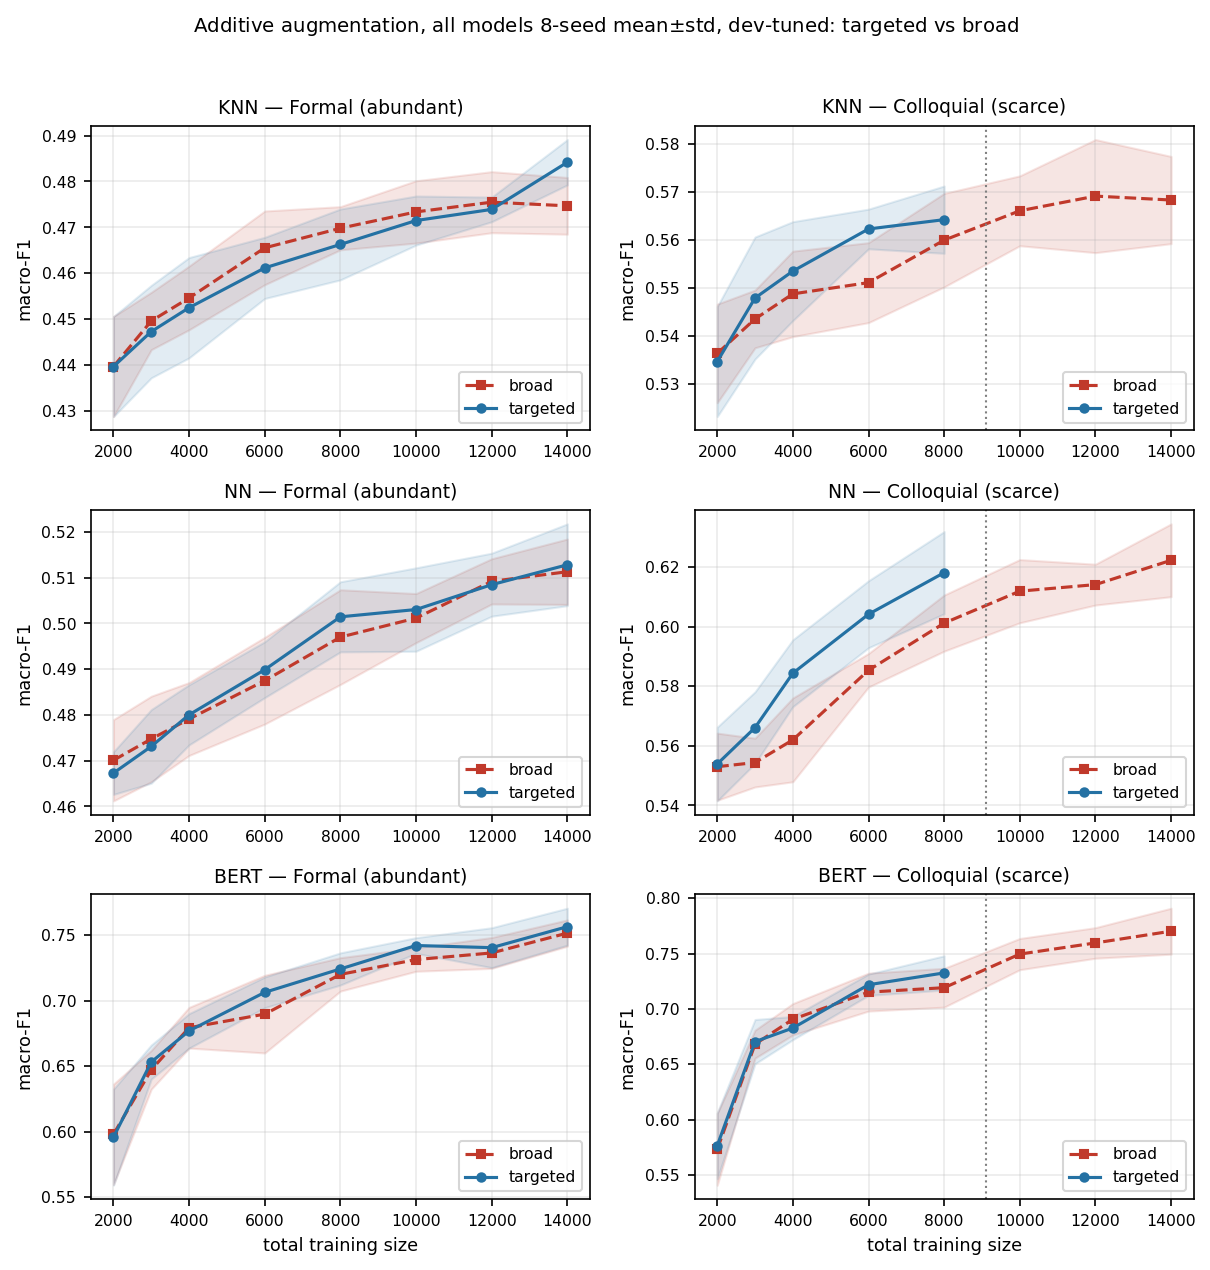

In [13]:
import json
from IPython.display import Image, display

R = json.load(open("results_augmentation.json"))
TOT = [2001, 3000, 3999, 6000, 8001, 9999, 12000, 14001]
print("통합 가산 증강 (세 모델 dev-튜닝, 증분 체크포인트)")
print("dev-선택 하이퍼파라미터:", R.get("_hparams"), "\n")
for m in ["KNN", "NN", "BERT"]:
    print(f"=== {m} ===")
    for tg in ["formal", "colloquial"]:
        print(f"[목표={tg}]    total | targeted |  broad")
        for N in TOT:
            tk = f"{m}/{tg}/targeted/{N}"; bk = f"{m}/{tg}/broad/{N}"
            ts = f"{R[tk]['mean']:.4f}" if tk in R else "—(고갈)"
            bs = f"{R[bk]['mean']:.4f}" if bk in R else "—"
            print(f"            {N:>6} | {ts:>9} | {bs:>6}")
        print()
print("핵심: 같은 크기엔 targeted 효율(특히 BERT). targeted는 ~9k서 고갈.")
print("      그 너머 broad 이득은 용량 비례 — BERT +0.040 vs KNN/NN +0.004.")
display(Image("fig_augmentation.png"))